In [1]:
import pandas as pd
from datetime import datetime, timedelta
from googleapiclient.discovery import build
import os
import re
import seaborn as sns
import matplotlib.pyplot as plt
from dotenv import load_dotenv
# Load environment variables from .env file
load_dotenv()

# Retrieve API key from environment variables
YOUTUBE_DEVELOPER_KEY = os.getenv('YOUTUBE_DEVELOPER_KEY')

# Verify API key is loaded
if not YOUTUBE_DEVELOPER_KEY:
    raise ValueError("YouTube API key not found. Please create a .env file with YOUTUBE_API_KEY=")
    
youtube = build('youtube', 'v3', developerKey=YOUTUBE_DEVELOPER_KEY)

In [3]:
def get_channel(channel_name):
    return youtube.search().list(q=channel_name, type='channel', part='id,snippet').execute()['items'][0]

In [5]:
channel_name = 'ThaiPBS'
CHANNEL_ID = get_channel(channel_name)['id']['channelId']
CHANNEL_ID

'UC5TOFhyb_LxL2VG_Zenhpzw'

In [7]:
# Function to get the channels stats
# It will also contain the upload playlist ID we can use to grab videos.
def get_channel_stats(youtube, channel_id):
    request = youtube.channels().list(
        part="snippet,contentDetails,statistics",
        id=channel_id
    )
    response = request.execute()
    
    return response['items']

In [9]:
# This will get us a list of videos from a playlist.
# Note a page of results has a max value of 50 so we will
# need to loop over our results with a pageToken

def get_video_list(youtube, upload_id):
    video_list = []
    request = youtube.playlistItems().list(
        part="snippet,contentDetails",
        playlistId=upload_id,
        maxResults=50
    )
    next_page = True
    while next_page:
        response = request.execute()
        data = response['items']

        for video in data:
            video_id = video['contentDetails']['videoId']
            if video_id not in video_list:
                video_list.append(video_id)

        # Do we have more pages?
        if 'nextPageToken' in response.keys():
            next_page = True
            request = youtube.playlistItems().list(
                part="snippet,contentDetails",
                playlistId=upload_id,
                pageToken=response['nextPageToken'],
                maxResults=50
            )
        else:
            next_page = False

    return video_list

In [11]:
# Once we have our video list we can pass it to this function to get details.
# Again we have a max of 50 at a time so we will use a for loop to break up our list. 

def get_video_details(youtube, video_list):
    stats_list=[]

    # Can only get 50 videos at a time.
    for i in range(0, len(video_list), 50):
        request= youtube.videos().list(
            part="snippet,contentDetails,statistics",
            id=video_list[i:i+50]
        )

        data = request.execute()
        for video in data['items']:
            video_id = video['id']  # Extract video_id            
            title=video['snippet']['title']
            published=video['snippet']['publishedAt']
            description=video['snippet']['description']
            # tag_count= len(video['snippet']['tags'])
            view_count=video['statistics'].get('viewCount',0)
            like_count=video['statistics'].get('likeCount',0)
            dislike_count=video['statistics'].get('dislikeCount',0)
            comment_count=video['statistics'].get('commentCount',0)
            # Include video_id in the dictionary
            stats_dict = dict(
                video_id=video_id,
                title=title,
                description=description,
                published=published,
                view_count=view_count,
                like_count=like_count,
                dislike_count=dislike_count,
                comment_count=comment_count
            )
            stats_list.append(stats_dict)

    return stats_list

In [13]:
channel_stats = get_channel_stats(youtube, CHANNEL_ID)

In [15]:
upload_id = channel_stats[0]['contentDetails']['relatedPlaylists']['uploads']
upload_id

'UU5TOFhyb_LxL2VG_Zenhpzw'

In [17]:
video_list = get_video_list(youtube, upload_id)
video_list[:10]

['qb-kLoOVvQI',
 'vAUYAQkbV-Y',
 'cjFYVtkrUE4',
 'WYCzvbF24Uw',
 'icndMeMzzPY',
 '_aZvtJ-SkMc',
 'v4TrwiL5vFU',
 'yzIrw-cTkVs',
 'icS4Aq59PB0',
 '2_fCJmbAsEo']

In [19]:
video_data = get_video_details(youtube, video_list)
'Number 0f Videos: ' + str(len(video_data))

'Number 0f Videos: 20000'

In [21]:
video_data[:10]

[{'video_id': 'qb-kLoOVvQI',
  'title': 'เศรษฐกิจเวียดนามโตแซงไทย กำลังบอกอะไรคนไทยบ้าง ? | เศรษฐกิจติดบ้าน',
  'description': 'ในช่วงหลายปีที่ผ่านมานี้ เรามักจะได้รับข้อมูลว่า เศรษฐกิจของประเทศเวียดนามโตขึ้นอย่างรวดเร็ว และกำลังจะแซงหน้าไทยในอีกไม่ช้า เนื่องมาจากการพัฒนาและการลงทุนในประเทศเวียดนามที่เพิ่มสูงขึ้น จนมีแนวโน้มว่าจะทำให้ระดับ GDP หรือรายได้ต่อหัวประชากรก็จะเพิ่มสูงขึ้นด้วย แล้วการโตขึ้นของเศรษฐกิจเวียดนามกำลังบอกอะไรกับคนไทยบ้าง ? ร่วมพูดคุยในประเด็นนี้กับ ดร.วิทย์ สิทธิเวคิน และคุณริชาร์ต วัชราทิตย์ เกษศรี\n\nติดตามชมช่วงเศรษฐกิจติดบ้าน ได้ในรายการวันใหม่วาไรตี้ วันจันทร์ – พฤหัสบดี เวลา 8.00 - 10.00 น. ทางไทยพีบีเอส\n\n#ไทยพีบีเอส #ThaiPBS #เศรษฐกิจติดบ้าน\n----------------------------------\n👉 ติดตาม ข่าว และรายการดี ๆ ย้อนหลัง ของ #ThaiPBS ได้ที่\nhttps://www.thaipbs.or.th และ https://www.youtube.com/ThaiPBS',
  'published': '2026-01-07T15:01:42Z',
  'view_count': '50',
  'like_count': '0',
  'dislike_count': 0,
  'comment_count': '0'},
 {'video_id': 'vAUYAQkbV-Y',
  

In [23]:
df=pd.DataFrame(video_data)
df.drop(columns=['dislike_count'], inplace=True)
df['title_length'] = df['title'].str.len()
# Convert 'published' to datetime
df['published'] = pd.to_datetime(df['published'])
# Format 'published' to "%Y-%m-%d"
df['published'] = df['published'].dt.strftime('%Y-%m-%d')
df["view_count"] = pd.to_numeric(df["view_count"])
df["like_count"] = pd.to_numeric(df["like_count"])
df["comment_count"] = pd.to_numeric(df["comment_count"])
# reaction used later add up likes + dislikes + comments
df["reactions"] = df["like_count"] + df["comment_count"] + df["comment_count"]

df.shape

(20000, 9)

In [25]:
df.dtypes

video_id         object
title            object
description      object
published        object
view_count        int64
like_count        int64
comment_count     int64
title_length      int64
reactions         int64
dtype: object

In [27]:
# Select rows where the title contains "Animation Maker"
result = df
result = df.query('title.str.lower().str.contains("นักผจญเพลง")', engine='python')
result.shape

(136, 9)

In [29]:
cols = 'video_id title published view_count title_length'.split()

In [31]:
# Retrieve the maximum value from the title_length column
max_title_length = result['title_length'].max()
print("Maximum title length:", max_title_length)
# Set pandas column display width to the maximum title_length value
pd.set_option('display.max_colwidth', max_title_length)
result[cols].sort_values(by='published', ascending=False).head(10)

Maximum title length: 96


,video_id,title,published,view_count,title_length
5249,jHoxPqH3-SY,ในเมื่อลูกชอบร้องเพลง ก็จัดเวทีให้ลูกไปเลยสิ | เรื่องเล่านักผจญเพลงREPLAY,2025-10-15,13902,73
5252,F02iu0tFBOk,ฝึกลิเก โหดขนาดไหน | เรื่องเล่านักผจญเพลง REPLAY,2025-10-15,14172,48
6452,da7mWRoTOFY,คนจนตรอก - วงตาวัน | นักผจญเพลง REPLAY,2025-09-20,4910,38
6454,IhbN555ZGu8,Sweetness - วงตาวัน | นักผจญเพลง REPLAY,2025-09-20,2309,39
6455,KdfO8excbUU,หัวใจธนู - วงตาวัน | นักผจญเพลง REPLAY,2025-09-20,1610,38
6456,1yBvq_x0_fs,เสียงกระซิบจากสายฝน - วงตาวัน | นักผจญเพลง REPLAY,2025-09-20,1223,49
6457,5fku_BeqfUo,หุ่นกระบอก - วงตาวัน | นักผจญเพลง REPLAY,2025-09-20,1624,40
6460,Fc5kNfjEkEI,40 ปี วงตาวัน | นักผจญเพลง REPLAY,2025-09-20,36783,33
6453,B1FPya8l-eo,ดูดาว - วงตาวัน | นักผจญเพลง REPLAY,2025-09-20,7876,35
7471,hziNamIkzfg,ถึงเวลา (wake) - LOMOSONIC | นักผจญเพลง REPLAY,2025-09-06,12971,46


In [35]:
# Just use this - it should work
csv_name = channel_name + '.csv'
result.to_csv(csv_name, encoding='utf-8-sig', index=False)

# Display results
print(f"✅ File saved: {csv_name}")
print(f"📊 Showing 10 most recent videos:")
display(result.sort_values(by="published", ascending=False).head(10))

✅ File saved: ThaiPBS.csv
📊 Showing 10 most recent videos:


,video_id,title,description,published,view_count,like_count,comment_count,title_length,reactions
5249,jHoxPqH3-SY,ในเมื่อลูกชอบร้องเพลง ก็จัดเวทีให้ลูกไปเลยสิ | เรื่องเล่านักผจญเพลงREPLAY,ในเมื่อลูกชอบร้องเพลง ก็จัดเวทีให้ลูกไปเลยสิ #กุ้งสุธิราช #จิ้งหรีดขาว #รายการThaiPBS\n\nติ...,2025-10-15,13902,118,1,73,120
5252,F02iu0tFBOk,ฝึกลิเก โหดขนาดไหน | เรื่องเล่านักผจญเพลง REPLAY,จะเป็นลิเก ต้องฝึกอะไรบ้าง ถ้าทนตรงนี้ได้ รอด นักผจญเพลง REPLAY ตอน กุ้ง สุธิราช x จิ้งหรีดข...,2025-10-15,14172,109,0,48,109
6452,da7mWRoTOFY,คนจนตรอก - วงตาวัน | นักผจญเพลง REPLAY,คนจนตรอก - วงตาวัน\nอัลบั้ม ม็อบ พ.ศ. 2535\n​ชมเต็มรายการ นักผจญเพลง REPLAY ตอน 40 ปี วงตาว...,2025-09-20,4910,29,0,38,29
6454,IhbN555ZGu8,Sweetness - วงตาวัน | นักผจญเพลง REPLAY,​Sweetness - วงตาวัน\nอัลบั้ม Autography พ.ศ. 2537\nชมเต็มรายการ นักผจญเพลง REPLAY ตอน 40 ป...,2025-09-20,2309,46,9,39,64
6455,KdfO8excbUU,หัวใจธนู - วงตาวัน | นักผจญเพลง REPLAY,หัวใจธนู - วงตาวัน\nอัลบั้ม 12 ราศี พ.ศ. 2536\n​ชมเต็มรายการ นักผจญเพลง REPLAY ตอน 40 ปี ว...,2025-09-20,1610,25,0,38,25
6456,1yBvq_x0_fs,เสียงกระซิบจากสายฝน - วงตาวัน | นักผจญเพลง REPLAY,เสียงกระซิบจากสายฝน - วงตาวัน\nอัลบั้ม หุ่นกระบอก พ.ศ. 2528\nชมเต็มรายการ นักผจญเพลง REPLA...,2025-09-20,1223,14,1,49,16
6457,5fku_BeqfUo,หุ่นกระบอก - วงตาวัน | นักผจญเพลง REPLAY,หุ่นกระบอก - วงตาวัน\nอัลบั้ม หุ่นกระบอก พ.ศ. 2528\n​ชมเต็มรายการ นักผจญเพลง REPLAY ตอน 40 ...,2025-09-20,1624,25,1,40,27
6460,Fc5kNfjEkEI,40 ปี วงตาวัน | นักผจญเพลง REPLAY,พาคุณผู้ชมไปพบกับ การกลับมารวมตัวของของศิลปินระดับตํานานอย่างวงตาวัน กลุ่มศิลปินที่เต็มไปด้ว...,2025-09-20,36783,1197,140,33,1477
6453,B1FPya8l-eo,ดูดาว - วงตาวัน | นักผจญเพลง REPLAY,ดูดาว - วงตาวัน\nอัลบั้ม ม็อบ พ.ศ. 2535\n​ชมเต็มรายการ นักผจญเพลง REPLAY ตอน 40 ปี วงตาวัน\...,2025-09-20,7876,193,20,35,233
7471,hziNamIkzfg,ถึงเวลา (wake) - LOMOSONIC | นักผจญเพลง REPLAY,ถึงเวลา (wake) - LOMOSONIC\nอัลบั้ม (ECHO & SILENCE) พ.ศ. 2556\n​ชมเต็มรายการ นักผจญเพลง REP...,2025-09-06,12971,159,1,46,161


In [37]:
df_highest_views = result.nlargest(10, 'view_count')
df_highest_views['title'] = df_highest_views['title'].str[:40]
df_highest_views['view_count_hundreds'] = df_highest_views['view_count'] / 30
df_highest_views

,video_id,title,description,published,view_count,like_count,comment_count,title_length,reactions,view_count_hundreds
13410,GXKO0zg1aCo,เจ็บจนพอ - WANYAi Feat. คิว Flure | นักผ,เจ็บจนพอ\nเนื้อร้อง/ทำนอง โอฬาร ชูใจ\nขับร้อง : WANYAi Feat.คิว Flure\n​ชมเต็มรายการ นักผจญ...,2025-06-14,15018697,8527,111,53,8749,500623.233333
10937,fVNEt8qNjSI,มารักทำไมตอนนี้ - ฝ้าย Am Fine | นักผจญเ,มารักทําไมตอนนี้ - Am Fine \nอัลบั้ม Hi-fine พ.ศ. 2549\n​ชมเต็มรายการ นักผจญเพลง REPLAY ตอน ...,2025-07-19,2794946,3717,177,50,4071,93164.866667
13899,nA81CYkO7DI,รักเธอสุดหัวใจ - ก้อง สหรัถ & Benja Band,รักเธอสุดหัวใจ - ก้อง สหรัถ\nOst. พิสูจน์รักจากสวรรค์ พ.ศ.2539\nขับร้อง : สหรัถ สังคปรีชา\nช...,2025-06-07,2744394,4160,113,60,4386,91479.800000
7472,eTfDYCHj3O8,ขอ (warm eyes) - LOMOSONIC | นักผจญเพลง,ขอ (warm eyes) - LOMOSONIC\nอัลบั้ม (ECHO & SILENCE) พ.ศ. 2556\n​ชมเต็มรายการ นักผจญเพลง REP...,2025-09-06,1012649,2269,95,46,2459,33754.966667
12912,pxkKIdU1XOE,ใจกลางเมือง - LABANOON | นักผจญเพลง REPL,​ใจกลางเมือง - ลาบานูน\nอัลบั้ม N.E.W.S. พ.ศ. 2559\nชมเต็มรายการ นักผจญเพลง REPLAY ตอน JOU...,2025-06-21,828149,850,29,42,908,27604.966667
17224,w-I9rglpo1I,ทิ้งรักลงแม่น้ำ - Y NOT 7 | นักผจญเพลง R,​ทิ้งรักลงแม่น้ำ\nอัลบั้ม Y Not 7 พ.ศ. 2537\nชมเต็มรายการ นักผจญเพลง REPLAY ตอน Y NOT 7 COME...,2025-04-19,827927,3898,142,45,4182,27597.566667
11469,6CB5J0MjSws,ขาดความอบอุ่น - เสือใหญ่ | นักผจญเพลง RE,ขาดความอบอุ่น \nอัลบั้ม เสือใหญ่ พ.ศ. 2548\n​ชมเต็มรายการ นักผจญเพลง REPLAY ตอน เสือใหญ่ x ...,2025-07-12,710279,2742,168,44,3078,23675.966667
12914,-aURrxfo0HI,เชือกวิเศษ - LABANOON | นักผจญเพลง REPLA,เชือกวิเศษ - ลาบานูน\nอัลบั้ม N.E.W.S. พ.ศ. 2559 \n​ชมเต็มรายการ นักผจญเพลง REPLAY ตอน JOUR...,2025-06-21,198696,667,34,41,735,6623.200000
10938,wziEXHAzL8s,ระหว่างเพื่อนกับแฟน - ขนมจีน กุลมาศ | นั,ระหว่างเพื่อนกับแฟน - ขนมจีน\nอัลบั้ม Spirit พ.ศ. 2551\n​ชมเต็มรายการ นักผจญเพลง REPLAY ตอน ...,2025-07-19,193148,1081,85,55,1251,6438.266667
8493,XKgRpOo_OpI,ผิดไหม - FAHRENHEIT | นักผจญเพลง REPLAY,ผิดไหม - ฟาเรนไฮต์ \nอัลบั้ม องศาฟาเรนไฮต์ พ.ศ. 2548\n​ชมเต็มรายการ นักผจญเพลง REPLAY ตอน FA...,2025-08-23,191787,1536,117,39,1770,6392.900000


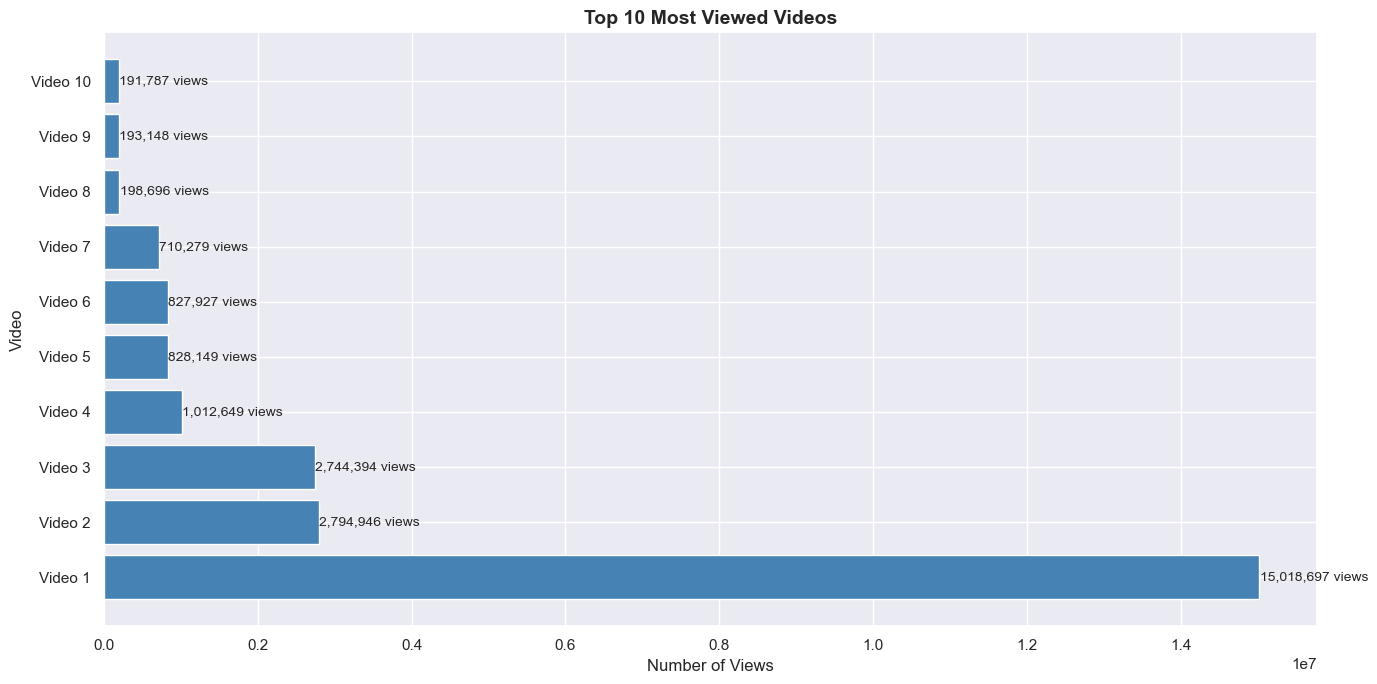


📊 **TOP 10 MOST VIEWED VIDEOS**
Rank   Video ID     Views        Published    Likes    Comments  
----------------------------------------------------------------------------------------------------
1      GXKO0zg1aCo  15,018,697   2025-06-14   8,527    111       
2      fVNEt8qNjSI  2,794,946    2025-07-19   3,717    177       
3      nA81CYkO7DI  2,744,394    2025-06-07   4,160    113       
4      eTfDYCHj3O8  1,012,649    2025-09-06   2,269    95        
5      pxkKIdU1XOE  828,149      2025-06-21   850      29        
6      w-I9rglpo1I  827,927      2025-04-19   3,898    142       
7      6CB5J0MjSws  710,279      2025-07-12   2,742    168       
8      -aURrxfo0HI  198,696      2025-06-21   667      34        
9      wziEXHAzL8s  193,148      2025-07-19   1,081    85        
10     XKgRpOo_OpI  191,787      2025-08-23   1,536    117       

📈 **Total views for top 5: 24,520,672**


In [39]:
# SIMPLE SOLUTION - No Thai characters at all
sns.set(rc={'figure.figsize':(16,8)})

# Create plot with video numbers instead of titles
df_plot = df_highest_views.copy()
df_plot['video_number'] = [f'Video {i+1}' for i in range(len(df_plot))]

# Create bar plot
plt.figure(figsize=(14, 7))
bars = plt.barh(df_plot['video_number'], df_plot['view_count'], color='steelblue')
plt.xlabel('Number of Views', fontsize=12)
plt.ylabel('Video', fontsize=12)
plt.title('Top 10 Most Viewed Videos', fontsize=14, fontweight='bold')

# Add value labels
for bar, views in zip(bars, df_plot['view_count']):
    width = bar.get_width()
    plt.text(width + 5000, bar.get_y() + bar.get_height()/2, 
             f'{views:,} views', va='center', fontsize=10)

plt.tight_layout()
plt.show()

# Create a markdown table for the console
print("\n📊 **TOP 10 MOST VIEWED VIDEOS**")
print("="*100)
print(f"{'Rank':<6} {'Video ID':<12} {'Views':<12} {'Published':<12} {'Likes':<8} {'Comments':<10}")
print("-"*100)

for i, (_, row) in enumerate(df_highest_views.iterrows()):
    print(f"{i+1:<6} {row['video_id']:<12} {row['view_count']:<12,} {row['published']:<12} {row['like_count']:<8,} {row['comment_count']:<10,}")

print("="*100)
print(f"\n📈 **Total views for top 5: {df_highest_views['view_count'].sum():,}**")

In [41]:
colt = 'video_id title published view_count'.split()
output_file = channel_name + '.csv'
df_highest_views[colt].to_csv(output_file, index=None)
df_highest_views.head(10)[colt].sort_values(by="view_count",ascending=False)

,video_id,title,published,view_count
13410,GXKO0zg1aCo,เจ็บจนพอ - WANYAi Feat. คิว Flure | นักผ,2025-06-14,15018697
10937,fVNEt8qNjSI,มารักทำไมตอนนี้ - ฝ้าย Am Fine | นักผจญเ,2025-07-19,2794946
13899,nA81CYkO7DI,รักเธอสุดหัวใจ - ก้อง สหรัถ & Benja Band,2025-06-07,2744394
7472,eTfDYCHj3O8,ขอ (warm eyes) - LOMOSONIC | นักผจญเพลง,2025-09-06,1012649
12912,pxkKIdU1XOE,ใจกลางเมือง - LABANOON | นักผจญเพลง REPL,2025-06-21,828149
17224,w-I9rglpo1I,ทิ้งรักลงแม่น้ำ - Y NOT 7 | นักผจญเพลง R,2025-04-19,827927
11469,6CB5J0MjSws,ขาดความอบอุ่น - เสือใหญ่ | นักผจญเพลง RE,2025-07-12,710279
12914,-aURrxfo0HI,เชือกวิเศษ - LABANOON | นักผจญเพลง REPLA,2025-06-21,198696
10938,wziEXHAzL8s,ระหว่างเพื่อนกับแฟน - ขนมจีน กุลมาศ | นั,2025-07-19,193148
8493,XKgRpOo_OpI,ผิดไหม - FAHRENHEIT | นักผจญเพลง REPLAY,2025-08-23,191787


In [43]:
# Get the user's home directory
user_path = os.path.expanduser('~')
# Get the current working directory
current_path = os.getcwd()
# Derive the base directory (base_dir) by removing the last folder ('Daily')
base_path = os.path.dirname(current_path)
#C:\Users\PC1\OneDrive\A5\Excel
xsl_path = os.path.join(base_path, "Excel")

In [45]:
print("User path:", user_path)
print(f"Current path: {current_path}")
print(f"Base path: {base_path}")
print(f"Excel path (xsl_path): {xsl_path}")

User path: C:\Users\PC1
Current path: C:\Users\PC1\OneDrive\A4\YouTube
Base path: C:\Users\PC1\OneDrive\A4
Excel path (xsl_path): C:\Users\PC1\OneDrive\A4\Excel


In [47]:
xsl_file = channel_name + '.xlsx'
xsl_file = os.path.join(xsl_path, xsl_file)
xsl_file

'C:\\Users\\PC1\\OneDrive\\A4\\Excel\\ThaiPBS.xlsx'

In [49]:
colt = 'video_id title published view_count read'.split()
df_highest_views['read'] = 'N'
df_highest_views[colt].to_excel(xsl_file, index=False)